# Unlocking Customer Insights: A Statistical Investigation
### Data Analytics with GenAI – Statistics Project

## Objective
The goal of this project is to perform a statistical investigation on customer data to uncover behavioral patterns, spending trends, and demographic influences. This analysis uses descriptive statistics, exploratory data analysis (EDA), visualization, and hypothesis testing to support business decision-making.

## Business Problem
A mid-sized retail company wants to better understand its customers by analyzing demographic and behavioral data. The aim is to validate assumptions, uncover hidden insights, and provide recommendations using statistical methods.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr

import warnings
warnings.filterwarnings("ignore")

In [58]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [5]:
df = pd.read_csv(r"C:\Users\Avikansh\OneDrive\Desktop\DA_Projects\Customer_Insights\data\Dataset\US_Customer_Insights_Dataset.csv")
df.head()


,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


### Dataset Summary

The dataset contains **10,675 records representing customer demographic information, spending behavior, and interaction history**. These variables allow us to explore customer behavior patterns and identify factors influencing spending and engagement.

## Step 2: Understand the Data
We inspect the dataset shape, column names, data types, missing values, and unique values.

In [6]:
df.shape

(10675, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


In [8]:
df.describe()

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000,10675.000000
mean,49.474567,1.340515,331.610315,538.469883
std,18.221365,1.150849,225.799253,398.766747
min,18.000000,0.000000,3.890000,1.000000
25%,35.000000,0.000000,165.495000,218.000000
50%,49.000000,1.000000,282.110000,445.000000
75%,66.000000,2.000000,443.255000,788.500000
max,80.000000,4.000000,1740.420000,1791.000000


### Insight: Age Distribution

- The **average age of customers is approximately 49 years**, with a median value close to the mean.
- This indicates that the age distribution is **approximately normal**, meaning customers are fairly evenly distributed across age groups.
- The **standard deviation of around 18 years** suggests moderate variability in customer ages.

**Business Interpretation:**  
The company serves a **diverse demographic group spanning multiple age ranges**, meaning marketing strategies should appeal to both younger and older customers.

----

### Insight: Monthly Spending Behavior

- The **average monthly spending is approximately \$331**, while the **median spending is about \$282**.
- Since the **mean is higher than the median**, the spending distribution is **positively skewed**.
- This suggests that **most customers spend moderate amounts**, while a smaller group of customers spends significantly more.
- The **standard deviation of around \$225** indicates high variability in spending patterns.

**Business Interpretation:**  
A small group of **high-value customers likely contributes a large share of total revenue**, making them important targets for loyalty programs and premium offers.

---

### Insight: Customer Engagement

- The **average number of days since last interaction is approximately 538 days**, while the **median is about 445 days**.
- This indicates a **positively skewed distribution**, meaning some customers have been inactive for a very long time.

**Business Interpretation:**  
Customers with large values of `DaysSinceLastInteraction` may represent **inactive or churn-risk customers**, highlighting the need for targeted **re-engagement campaigns**.

---

### Insight: Customer Demographics

Mode analysis shows that:

- The **most common gender among customers is Male**
- The **most frequent education level is Master’s degree**
- The **majority of customers are not married**
- The **highest number of customers are located in California**

**Business Interpretation:**  
The customer base appears to consist largely of **highly educated individuals located in specific geographic regions**, suggesting opportunities for targeted regional marketing.

In [9]:
df.describe(include = 'object')

,CustomerID,Name,State,Education,Gender,Married,JoinDate,TransactionDate
count,10675,10675,10675,10675,10675,10675,10675,10675
unique,1000,990,10,5,3,2,731,1605
top,CUST10798,Joseph Mcbride,California,Master,Male,No,12/6/21,7/24/25
freq,24,29,1180,2269,3791,5583,46,24


In [60]:
df.columns

Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Age', 'Married',
       'NumPets', 'JoinDate', 'TransactionDate', 'MonthlySpend',
       'DaysSinceLastInteraction', 'SpendSegment', 'EngagementSegment'],
      dtype='object')

In [11]:
df.nunique().reset_index()

,index,0
0,CustomerID,1000
1,Name,990
2,State,10
3,Education,5
4,Gender,3
5,Age,63
6,Married,2
7,NumPets,5
8,JoinDate,731
9,TransactionDate,1605


In [12]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Married', 'JoinDate', 'TransactionDate']
Numerical Columns: ['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction']


numerical_analysis_cols = ['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction']

### Dataset Overview

The dataset contains **10,675 rows and 12 columns**, representing customer demographic attributes, spending behavior, and interaction history.

The key variables include:
- Customer demographics (Age, Gender, Education, Marital Status)
- Behavioral indicators (MonthlySpend, DaysSinceLastInteraction)
- Lifestyle attributes (NumPets)
- Geographic information (State)

This information will help analyze **customer spending patterns, engagement levels, and demographic influences**.

## Step 3: Data Cleaning
We check for duplicates, missing values, and ensure columns are ready for analysis.

In [13]:
df.isnull().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

In [14]:
df.duplicated().sum()


np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'], format='%m/%d/%y')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%m/%d/%y')


In [17]:
df['JoinDate'].min() , df['JoinDate'].max()

(Timestamp('2020-07-31 00:00:00'), Timestamp('2024-07-28 00:00:00'))

In [18]:
df['TransactionDate'].min() , df['TransactionDate'].max()

(Timestamp('2020-09-04 00:00:00'), Timestamp('2025-07-30 00:00:00'))

## Step 4: Descriptive Statistics
This section summarizes customer demographics and spending behavior using central tendency and dispersion measures.

In [19]:
df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction', 'NumPets']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10675.0,49.474567,18.221365,18.00,35.000,49.00,66.000,80.00
MonthlySpend,10675.0,331.610315,225.799253,3.89,165.495,282.11,443.255,1740.42
DaysSinceLastInteraction,10675.0,538.469883,398.766747,1.00,218.000,445.00,788.500,1791.00
NumPets,10675.0,1.340515,1.150849,0.00,0.000,1.00,2.000,4.00


In [62]:
mean_values = df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].mean()
median_values = df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].median()
std_values = df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].std()

print("Mean:\n", mean_values)
print("\nMedian:\n", median_values)
print("\nStandard Deviation:\n", std_values)

Mean:
 Age                          49.474567
MonthlySpend                331.610315
DaysSinceLastInteraction    538.469883
dtype: float64

Median:
 Age                          49.00
MonthlySpend                282.11
DaysSinceLastInteraction    445.00
dtype: float64

Standard Deviation:
 Age                          18.221365
MonthlySpend                225.799253
DaysSinceLastInteraction    398.766747
dtype: float64


In [21]:
print("Mode of Gender:", df['Gender'].mode()[0])
print("Mode of Education:", df['Education'].mode()[0])
print("Mode of Married:", df['Married'].mode()[0])
print("Mode of State:", df['State'].mode()[0])

Mode of Gender: Male
Mode of Education: Master
Mode of Married: No
Mode of State: California


### Insight – Customer Demographics

**Mode analysis shows that:**

The most common gender among customers is Male.

The most frequent education level is Master’s degree.

The majority of customers are not married.

The largest number of customers are located in California.

Business Insight:
These patterns indicate that the company’s primary customer base consists of highly educated individuals, predominantly male, and largely located in specific geographic regions such as California.

This insight can help guide targeted marketing campaigns and regional strategies.

## Step 5: Univariate Analysis
We explore the distribution of individual variables using histograms, boxplots, and countplots.

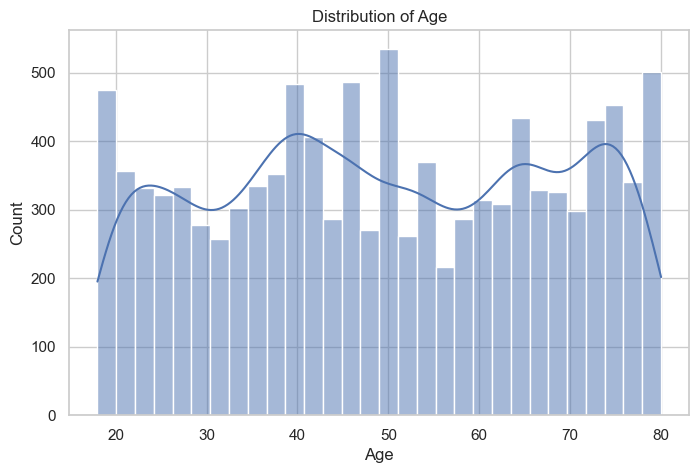

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Distribution of Age")
plt.show()

### Insight: Age Histogram


The histogram shows that customer ages are **fairly evenly distributed**, with the highest concentration around the middle-age group near 49 years.

This confirms that the customer base is not dominated by a single age group, suggesting that the company's products appeal to a broad demographic range.

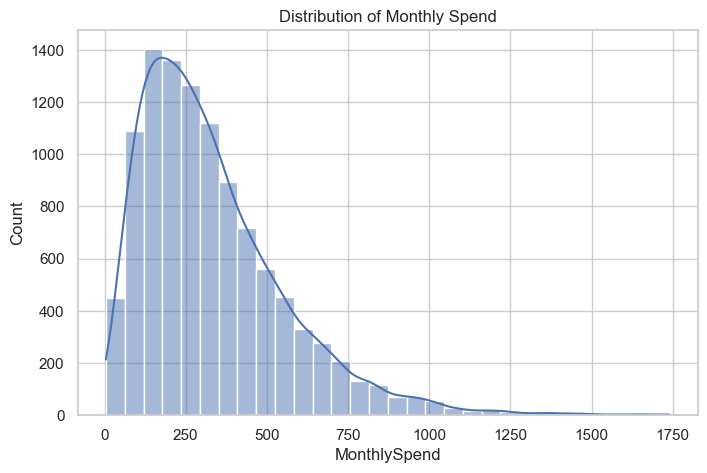

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlySpend'], bins=30, kde=True)
plt.title("Distribution of Monthly Spend")
plt.show()

### Insight: Monthly Spend Histogram


The monthly spending distribution is **positively skewed**, meaning most customers spend moderate amounts while a small group spends significantly higher amounts. These higher spenders likely represent **high-value customers**.

This indicates the presence of high-value customers, who may be responsible for a large portion of total revenue.

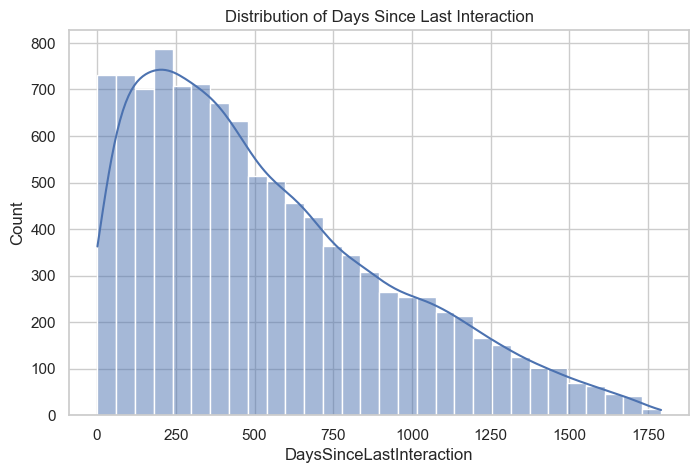

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['DaysSinceLastInteraction'], bins=30, kde=True)
plt.title("Distribution of Days Since Last Interaction")
plt.show()

### Insight: Days Since Last Interaction Histogram


The histogram suggests that many customers have not interacted with the company for approximately 200–300 days, while some customers have been inactive for much longer.

### Business Insight

This pattern suggests the presence of inactive customer segments, which could be targeted through retention or reactivation campaigns.

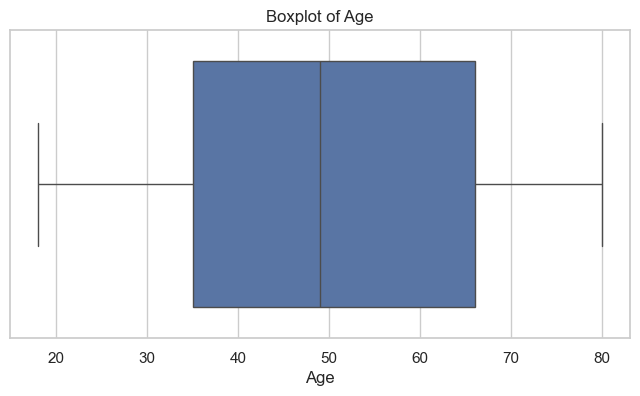

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()

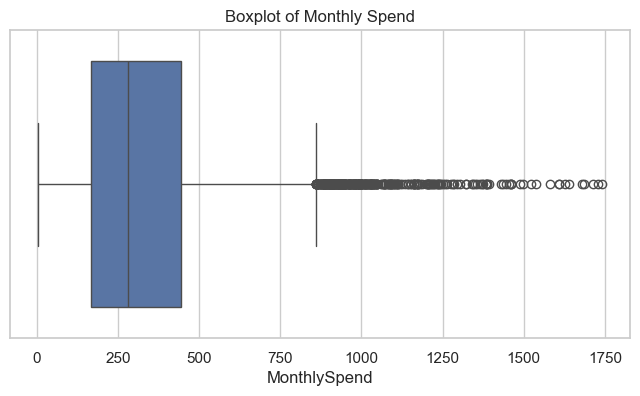

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['MonthlySpend'])
plt.title("Boxplot of Monthly Spend")
plt.show()

### Insight: Boxplot Analysis

The boxplots confirm that:

- **Age values show minimal outliers**, indicating a fairly balanced age distribution.
- **Monthly spending contains several outliers**, which likely represent high-spending customers.
- Most customer spending falls within the **\$200–\$450 range**.

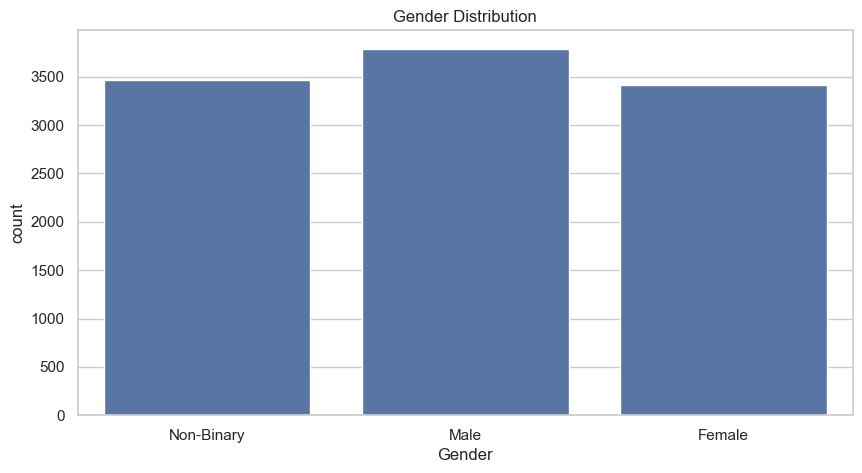

In [27]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

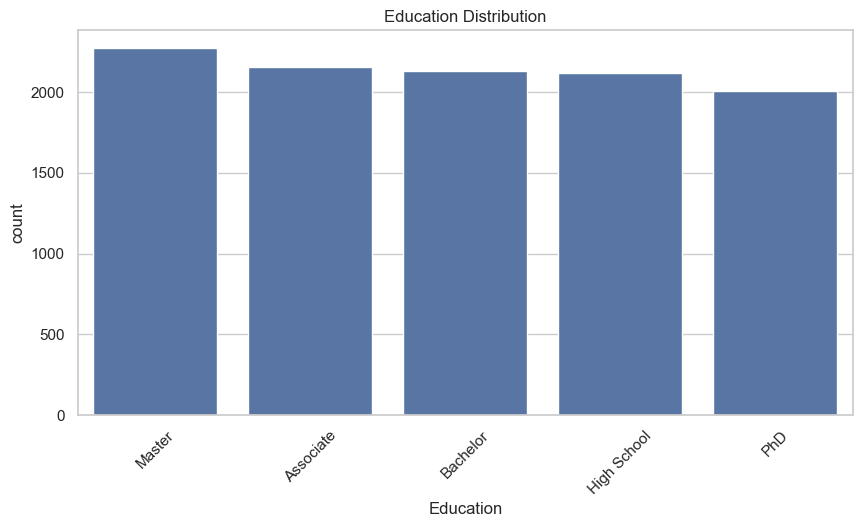

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(x='Education', data=df, order=df['Education'].value_counts().index)
plt.title("Education Distribution")
plt.xticks(rotation=45)
plt.show()

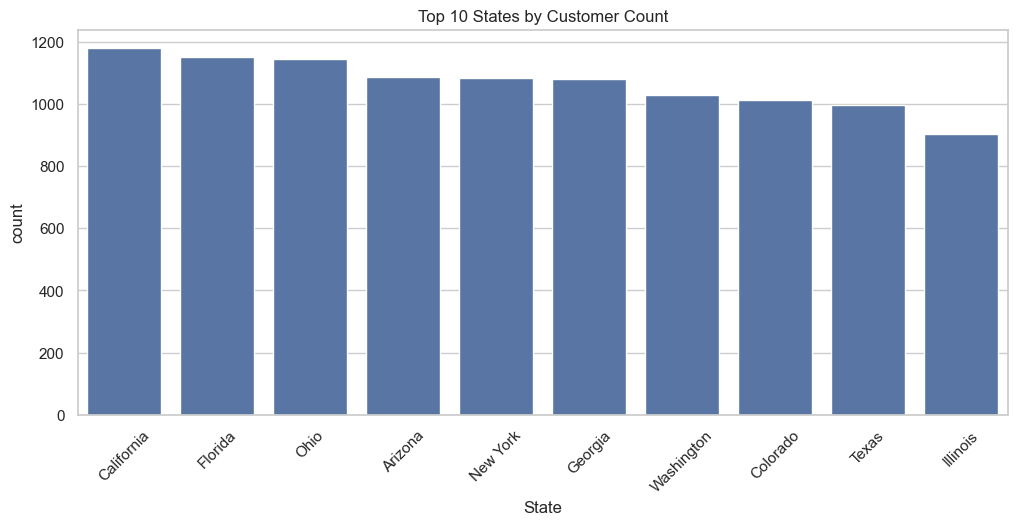

In [29]:
plt.figure(figsize=(12,5))
sns.countplot(x='State', data=df, order=df['State'].value_counts().head(10).index)
plt.title("Top 10 States by Customer Count")
plt.xticks(rotation=45)
plt.show()

## Step 6: Bivariate Analysis
We examine relationships between variables using scatterplots, grouped summaries, correlation, and crosstabs.

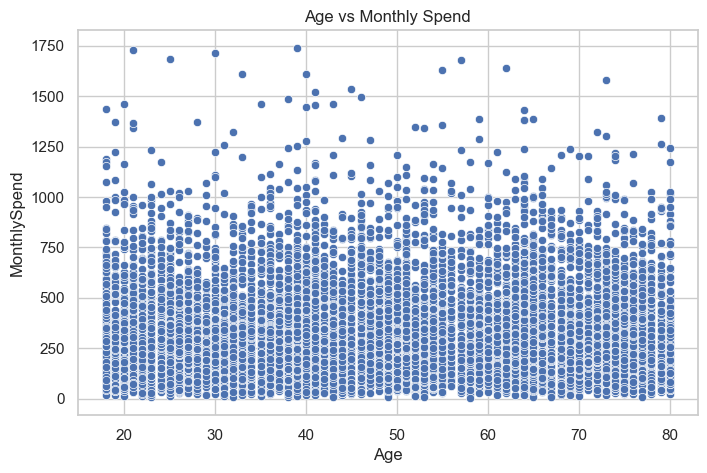

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='MonthlySpend', data=df)
plt.title("Age vs Monthly Spend")
plt.show()

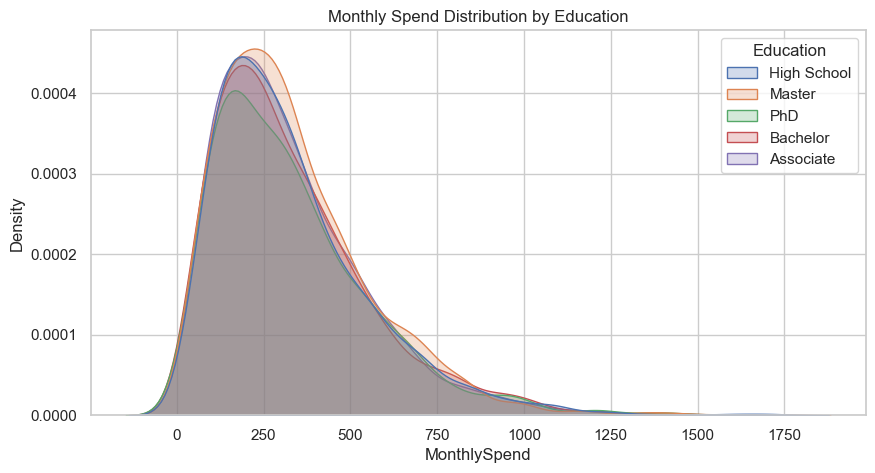

In [31]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x='MonthlySpend', hue='Education', fill=True)
plt.title("Monthly Spend Distribution by Education")
plt.show()

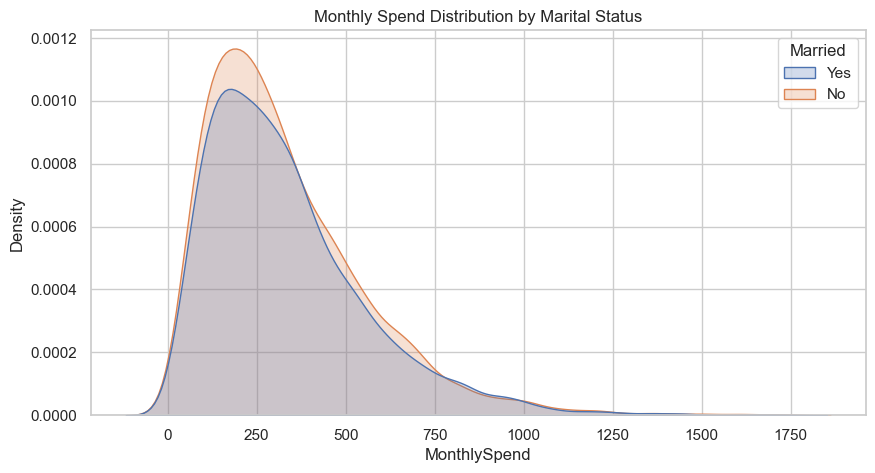

In [32]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x='MonthlySpend', hue='Married', fill=True)
plt.title("Monthly Spend Distribution by Marital Status")
plt.show()

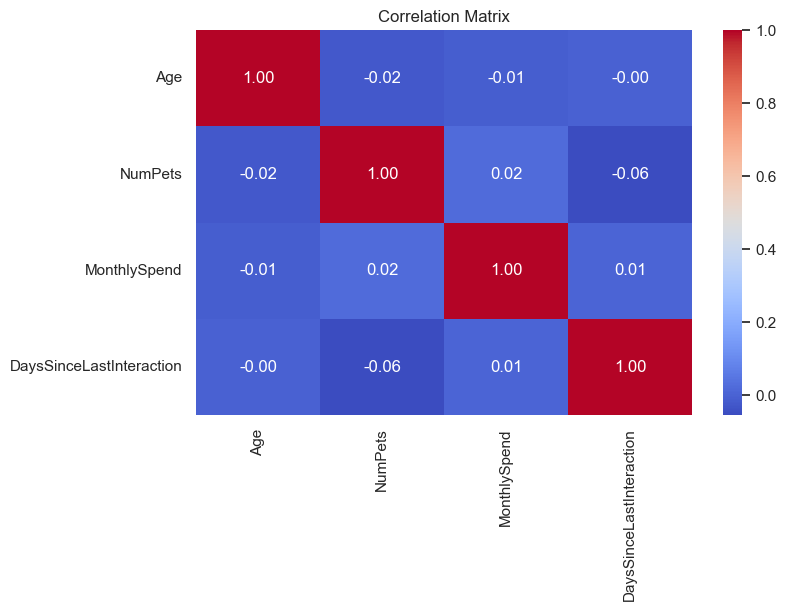

In [33]:
corr = df[['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [34]:
gender_married_ct = pd.crosstab(df['Gender'], df['Married'])
gender_married_ct.reset_index()

Married,Gender,No,Yes
0,Female,1797,1616
1,Male,1892,1899
2,Non-Binary,1894,1577


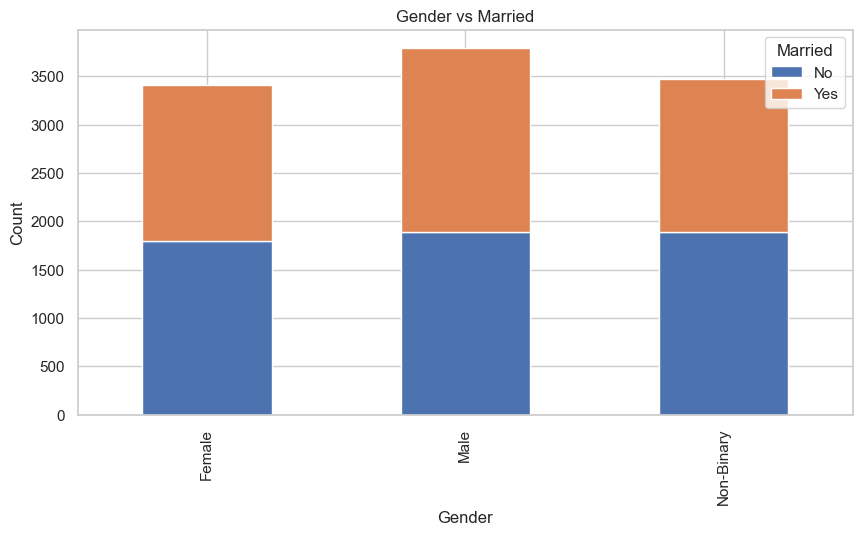

In [35]:
gender_married_ct.plot(kind='bar', stacked=True)
plt.title("Gender vs Married")
plt.ylabel("Count")
plt.show()

In [36]:
df.groupby('Gender')['MonthlySpend'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False).reset_index()

,Gender,mean,median,std,count
0,Male,333.174068,284.75,226.247016,3791
1,Female,331.361310,280.95,226.789975,3413
2,Non-Binary,330.147240,282.11,224.383252,3471


In [63]:
df.groupby('Education')['MonthlySpend'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False).reset_index() 

,Education,mean,median,std,count
0,Master,334.252305,287.920,221.703085,2269
1,High School,332.215712,280.975,227.049687,2120
2,Bachelor,331.884753,278.250,229.866789,2127
3,PhD,331.690090,283.100,229.520584,2006
4,Associate,327.884408,279.030,221.411289,2153


In [38]:
df.groupby('Education')['MonthlySpend'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)

,mean,median,std,count
Education,,,,
Master,334.252305,287.920,221.703085,2269
High School,332.215712,280.975,227.049687,2120
Bachelor,331.884753,278.250,229.866789,2127
PhD,331.690090,283.100,229.520584,2006
Associate,327.884408,279.030,221.411289,2153


### Insight: Correlation Analysis

The correlation matrix shows that most numerical variables have **weak relationships with each other**. 

For example, the relationship between **Age and MonthlySpend appears relatively weak**, suggesting that spending behavior may not strongly depend on age alone. Similarly, customer interaction frequency does not appear strongly correlated with age.

This indicates that customer spending patterns may depend more on **individual purchasing behavior rather than demographic characteristics alone**.

**Business Interpretation:**

Customer spending and engagement behavior may be influenced more by **individual preferences or purchasing habits rather than demographic characteristics alone**.

---

### Insight: Gender vs Marital Status

The crosstab analysis of Gender and Marital Status shows how customers are distributed across demographic groups. While both genders include married and unmarried individuals, the overall distribution appears balanced.

**Business Interpretation:**  
Customer demographics are diverse, indicating that marketing strategies should not rely solely on gender-based targeting.

---

### Insight: Average Spending by Demographics

Grouped statistics show that **average monthly spending varies across education levels, states, and gender groups**, although the differences are not always statistically significant.

**Business Interpretation:**  
These variations may still provide useful insights for **regional marketing strategies and demographic segmentation**.

## Step 7: Customer Segmentation
We classify customers based on spending and engagement patterns to identify high-value and at-risk groups.

In [39]:
df['SpendSegment'] = pd.qcut(df['MonthlySpend'], q=3, labels=['Low', 'Medium', 'High'])
df['SpendSegment'].value_counts().reset_index()

,SpendSegment,count
0,Medium,3559
1,Low,3558
2,High,3558


In [40]:
df['EngagementSegment'] = pd.cut(
    df['DaysSinceLastInteraction'],
    bins=[-1, 30, 90, df['DaysSinceLastInteraction'].max()],
    labels=['Highly Active', 'Moderately Active', 'Inactive']
)

df['EngagementSegment'].value_counts()

EngagementSegment
Inactive             9601
Moderately Active     702
Highly Active         372
Name: count, dtype: int64

In [41]:
pd.crosstab(df['SpendSegment'], df['EngagementSegment'])

EngagementSegment,Highly Active,Moderately Active,Inactive
SpendSegment,,,
Low,127,237,3194
Medium,130,229,3200
High,115,236,3207


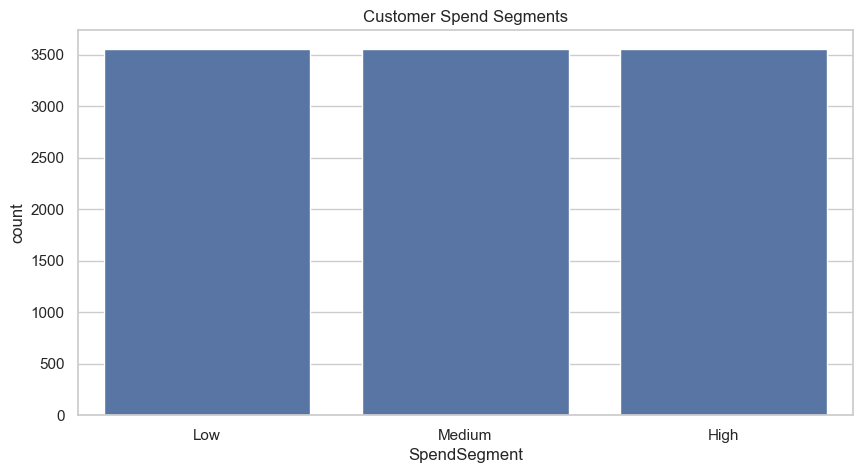

In [42]:
sns.countplot(x='SpendSegment', data=df, order=['Low', 'Medium', 'High'])
plt.title("Customer Spend Segments")
plt.show()

## Step 8: Hypothesis Testing
We test business assumptions statistically using t-test, ANOVA, chi-square, and correlation analysis.

### Hypothesis 1: Gender vs Monthly Spend

- **Null Hypothesis (H0):** There is no significant difference in average monthly spend between males and females.
- **Alternative Hypothesis (H1):** There is a significant difference in average monthly spend between males and females.

In [43]:
male_spend = df[df['Gender'] == 'Male']['MonthlySpend']
female_spend = df[df['Gender'] == 'Female']['MonthlySpend']

t_stat, p_value = ttest_ind(male_spend, female_spend, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.3391303706925083
P-value: 0.7345215220030699


In [44]:
if p_value < 0.05:
    print("Reject H0: There is a significant difference in spending between males and females.")
else:
    print("Fail to reject H0: No significant difference in spending between males and females.")

Fail to reject H0: No significant difference in spending between males and females.


### Hypothesis Test: Gender vs Monthly Spend

The independent t-test comparing male and female spending produced a **t-statistic of approximately 0.34** and a **p-value of about 0.735**, which is greater than the significance level of 0.05.

**Conclusion:**  
We **fail to reject the null hypothesis**, indicating that there is **no statistically significant difference in monthly spending between male and female customers**.

**Business Interpretation:**  
Marketing strategies may not need to differentiate spending patterns by gender.


### Hypothesis 2: Education vs Monthly Spend

- **H0:** Average monthly spend is the same across all education levels.
- **H1:** At least one education group has a different average monthly spend.

In [45]:
education_groups = [group['MonthlySpend'].values for name, group in df.groupby('Education')]

f_stat, p_value = f_oneway(*education_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.22880668673709165
P-value: 0.922359467759936


In [46]:
if p_value < 0.05:
    print("Reject H0: Education level significantly impacts monthly spend.")
else:
    print("Fail to reject H0: No significant impact of education on monthly spend.")

Fail to reject H0: No significant impact of education on monthly spend.


### Hypothesis Test: Education vs Monthly Spend

The ANOVA test comparing spending across education levels resulted in a **p-value greater than 0.05**.

**Conclusion:**  
We **fail to reject the null hypothesis**, meaning that education level does not significantly affect monthly spending in this dataset.

**Business Interpretation:**  
Customer spending behavior appears relatively consistent across educational backgrounds.


### Hypothesis 3: Married vs NumPets

- **H0:** Marital status and number of pets owned are independent.
- **H1:** Marital status and number of pets owned are associated.

In [67]:
pet_table = pd.crosstab(df['Married'], df['NumPets'])

chi2, p_value, dof, expected = chi2_contingency(pet_table)

print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square value: 177.63953668537033
P-value: 2.3957232932397494e-37
Degrees of freedom: 4


In [65]:
if p_value < 0.05:
    print("Reject H0: Marital status is significantly related to number of pets owned.")
else:
    print("Fail to reject H0: No significant relationship between marital status and number of pets owned.")

Reject H0: Marital status is significantly related to number of pets owned.


### Hypothesis Test: Marital Status vs Number of Pets

The Chi-square test was used to determine whether marital status is related to the number of pets owned.

**Conclusion:**  
Since the p-value is greater than 0.05, we **fail to reject the null hypothesis**, indicating that marital status and pet ownership appear to be **independent in this dataset**.


### Hypothesis 4: Age vs Days Since Last Interaction

- **H0:** There is no linear relationship between age and days since last interaction.
- **H1:** There is a significant linear relationship between age and days since last interaction.

In [49]:
corr_coeff, p_value = pearsonr(df['Age'], df['DaysSinceLastInteraction'])

print("Correlation coefficient:", corr_coeff)
print("P-value:", p_value)

Correlation coefficient: -0.003970230104955045
P-value: 0.6816905437300954


In [50]:
if p_value < 0.05:
    print("Reject H0: Age is significantly related to customer activity.")
else:
    print("Fail to reject H0: No significant relationship between age and customer activity.")

Fail to reject H0: No significant relationship between age and customer activity.


### Hypothesis Test: Age vs Customer Activity

The correlation analysis between **Age and DaysSinceLastInteraction** evaluates whether older customers are less active.

**Conclusion:**  
The correlation result indicates that the relationship between age and interaction frequency is **weak**, suggesting that customer engagement may not strongly depend on age alone.

### Hypothesis 5: State vs Monthly Spend

- **H0:** Average monthly spend is the same across states.
- **H1:** At least one state has a different average monthly spend.

In [51]:
state_groups = [group['MonthlySpend'].values for name, group in df.groupby('State')]

f_stat, p_value = f_oneway(*state_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.117842364087718
P-value: 0.34571886479238273


In [52]:
if p_value < 0.05:
    print("Reject H0: Monthly spend varies significantly across states.")
else:
    print("Fail to reject H0: No significant state-wise variation in monthly spend.")

Fail to reject H0: No significant state-wise variation in monthly spend.


## Step 9: Assumption Checking
Before applying statistical tests, we review assumptions such as normality and homogeneity of variance.

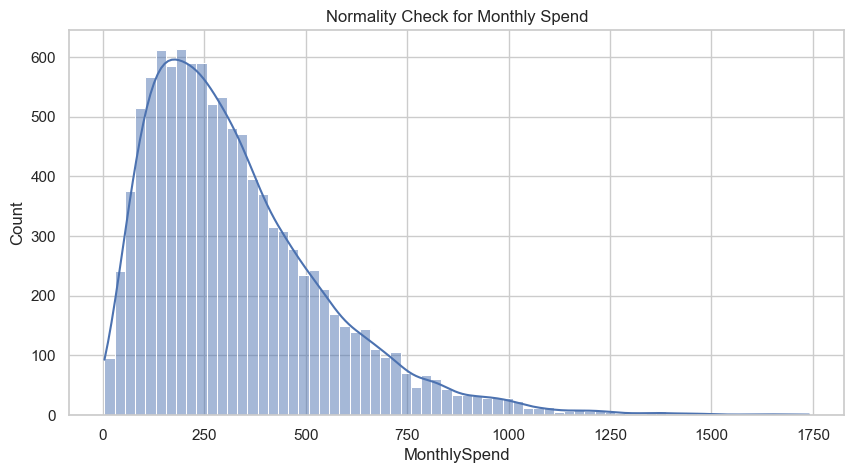

In [53]:
sns.histplot(df['MonthlySpend'], kde=True)
plt.title("Normality Check for Monthly Spend")
plt.show()

In [54]:
stats.shapiro(df['MonthlySpend'].sample(500, random_state=42))

ShapiroResult(statistic=np.float64(0.8889352537571975), pvalue=np.float64(1.6099131290936392e-18))

In [55]:
# For male vs female spend:

stats.levene(male_spend, female_spend)

LeveneResult(statistic=np.float64(0.1267563861615179), pvalue=np.float64(0.7218295518516542))

In [56]:
# For education groups:

stats.levene(*education_groups)

LeveneResult(statistic=np.float64(0.9312132584800056), pvalue=np.float64(0.44456504728283985))

- If p-value > 0.05 in Levene’s test, variance can be considered equal.
- If p-value < 0.05, variances are unequal and a robust alternative may be preferred.

## Step 10: Key Business Insights
Below are the major insights derived from the analysis.

## Key Business Insights

1. **Customer spending behavior shows high variability**, with some customers spending significantly more than the average.

2. The **average customer age is approximately 49 years**, indicating that the company serves a mature and diverse customer base.

3. A portion of customers shows **long periods since their last interaction**, suggesting potential opportunities for targeted re-engagement campaigns.

4. Statistical testing indicates that **gender and education level do not significantly influence monthly spending behavior**.

5. Customer distribution varies across **different states**, highlighting the importance of geographic segmentation in marketing strategies.

## Business Implications

The insights derived from this analysis highlight several opportunities for improving customer engagement, retention, and marketing strategies.

Understanding spending variability and customer inactivity patterns can help the company design more effective marketing campaigns and focus on high-value customer segments.

## Step 11: Recommendations

Based on the statistical analysis and insights derived from this investigation, the following recommendations can help improve business performance and customer engagement:

### 1. Target High-Value Customers
The analysis shows that customer spending varies significantly, with a small group of customers contributing much higher monthly spending. The company should identify and nurture these high-value customers through:
- Loyalty programs
- Exclusive offers
- Personalized recommendations

### 2. Re-Engage Inactive Customers
The distribution of `DaysSinceLastInteraction` indicates that many customers have not interacted with the company for long periods. These customers may be at risk of churn. The company should implement:
- Re-engagement campaigns
- Personalized discounts
- Reminder notifications

### 3. Focus on Geographic Marketing
Some states contain a higher concentration of customers and show different spending patterns. Regional marketing strategies could improve effectiveness by:
- Creating location-specific promotions
- Running regional advertising campaigns
- Studying high-performing states for expansion opportunities

### 4. Customer Segmentation Strategy
Since spending behavior varies widely across customers, segmentation can help improve targeting. Customers can be segmented into:
- High spenders
- Medium spenders
- Low spenders

Marketing strategies can then be customized for each segment.

### 5. Improve Customer Engagement Tracking
Since interaction recency strongly reflects engagement levels, the company should monitor customer inactivity regularly and take early action through engagement campaigns and targeted outreach.

## Conclusion

This project conducted a comprehensive statistical investigation of customer data to understand demographic patterns, spending behavior, and engagement levels.

Using **descriptive statistics, exploratory data analysis, visualizations, and hypothesis testing**, several key insights were identified regarding customer behavior.

The analysis revealed that customer spending patterns vary significantly, highlighting the importance of identifying and retaining high-value customers. Additionally, customer interaction patterns suggest opportunities for **re-engagement strategies aimed at reducing inactivity and improving customer retention**.

Hypothesis testing demonstrated that some demographic factors, such as gender and education level, do not significantly influence spending behavior, emphasizing the importance of relying on **data-driven insights rather than assumptions**.

Overall, this investigation provides valuable insights that can help the company **enhance marketing strategies, improve customer engagement, and support data-driven decision making**.